In [1]:
import pandas as pd
import external_func as ef
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url_1 = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_demo.txt"
client_info_df = pd.read_csv(url_1, sep=",")
url_2 = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_experiment_clients.txt"
groups_df = pd.read_csv(url_2, sep=",")
url_pt_1 = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_1.txt"
df_1 = pd.read_csv(url_pt_1)
url_pt_2 = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_web_data_pt_2.txt"
df_2 = pd.read_csv(url_pt_2)

In [3]:
groups_df = ef.columns_formating(groups_df)

In [16]:
web_activity_df = pd.concat([df_1, df_2], axis=0, ignore_index=True)
web_activity_df["date_time"] = pd.to_datetime(web_activity_df["date_time"])
df_all = pd.merge(web_activity_df, groups_df, on='client_id', how='left')
df_all = df_all[df_all["variation"].notnull()]
df_all = df_all.sort_values(by=['visit_id', 'date_time']).reset_index(drop=True)
df_all = df_all[df_all.duplicated(subset=['visit_id', 'client_id', 'visitor_id', 'process_step', 'date_time']) == False]
df_all["process_step"] = df_all["process_step"].map({'start': 1, 'step_1': 2, 'step_2': 3, 'step_3': 4, 'confirm': 5})

df_all

,client_id,visitor_id,visit_id,process_step,date_time,variation
0,3561384,451664975_1722933822,100012776_37918976071_457913,5,2017-04-26 13:22:17,Test
1,3561384,451664975_1722933822,100012776_37918976071_457913,5,2017-04-26 13:23:09,Test
2,7338123,612065484_94198474375,100019538_17884295066_43909,1,2017-04-09 16:20:56,Test
3,7338123,612065484_94198474375,100019538_17884295066_43909,2,2017-04-09 16:21:12,Test
4,7338123,612065484_94198474375,100019538_17884295066_43909,3,2017-04-09 16:21:21,Test
...,...,...,...,...,...,...
321304,6627522,730634087_44272418812,999988789_76411676596_272843,1,2017-04-21 23:49:11,Test
321305,6627522,730634087_44272418812,999988789_76411676596_272843,2,2017-04-21 23:49:22,Test
321306,6627522,730634087_44272418812,999988789_76411676596_272843,3,2017-04-21 23:50:16,Test
321307,6627522,730634087_44272418812,999988789_76411676596_272843,2,2017-04-21 23:51:00,Test


In [17]:
journey_check = (df_all.groupby('visit_id')['process_step'].apply(list).reset_index(name='journey'))
journey_check.head(5)

,visit_id,journey
0,100012776_37918976071_457913,"[5, 5]"
1,100019538_17884295066_43909,"[1, 2, 3, 2, 2, 1, 1, 2, 3, 4, 5]"
2,100022086_87870757897_149620,"[1, 2, 3, 4, 5]"
3,100030127_47967100085_936361,[1]
4,100037962_47432393712_705583,"[1, 1, 2, 1]"


1. Preparing samples from test-population and control population

In [30]:
sample_visits = (df_all.sample(10, random_state=42))
sample_visits.sort_values(['client_id', 'visit_id', 'process_step', 'date_time'])

,client_id,visitor_id,visit_id,process_step,date_time,variation,step_info
210259,370651,250857360_36740647962,68961774_43618302815_544394,1,2017-05-14 16:48:39,Control,0
254518,1113765,247393431_12143612062,812587021_83374994214_819680,4,2017-04-06 11:25:01,Control,1
68814,1221967,419628479_88830520517,293832311_33663918686_831101,2,2017-04-08 12:27:34,Control,1
169557,1918431,503341114_94219012772,577235056_35199331472_355124,4,2017-03-23 22:31:07,Control,1
51738,2390984,662323033_23953794544,245264285_59581094109_17550,1,2017-04-06 12:08:29,Test,0
313531,3946278,247329183_54294222633,978799885_32622204433_200382,3,2017-04-14 00:25:22,Test,1
200582,3977195,176135557_28853454494,662725219_4936657973_693378,5,2017-04-06 13:17:27,Test,1
275835,4865096,284091468_95621546445,871540110_6461807938_114943,1,2017-03-29 11:27:35,Test,0
136432,7598836,273233505_60400351574,483664267_82600202849_480645,2,2017-04-09 17:05:00,Control,-1
68265,8501790,610130905_42862818355,292246452_33155987238_930021,1,2017-04-14 10:38:17,Test,0


**Conclusion**
The data from random sample give us the information about random destributio of client's web activities. We've got random data in all columns

2. Data preparation for KPI calculations

In [19]:
confirmed_path = [1,2,3,4,5]
journey_check['ideal_order_and_completed'] = journey_check['journey'].apply(lambda x: x == confirmed_path)

journey_check['ideal_order_and_completed'].value_counts()

ideal_order_and_completed
False    49381
True     19824
Name: count, dtype: int64

In [22]:
df_all = df_all.sort_values(['client_id', 'date_time'])
df_all["step_info"] = (df_all["process_step"] - (df_all.groupby("client_id")["process_step"].shift(1)).fillna(df_all["process_step"])).map(int)


In [31]:
df_all.head(3)

,client_id,visitor_id,visit_id,process_step,date_time,variation,step_info
191129,555,402506806_56087378777,637149525_38041617439_716659,1,2017-04-15 12:57:56,Test,0
191130,555,402506806_56087378777,637149525_38041617439_716659,2,2017-04-15 12:58:03,Test,1
191131,555,402506806_56087378777,637149525_38041617439_716659,3,2017-04-15 12:58:35,Test,1


2. Preparation web activity data for test group

In [231]:
t_gr = df_all[(df_all["variation"] == "Test")]
test_clients_any = t_gr.groupby('client_id')['process_step'].agg(list).reset_index()
test_clients = (t_gr.groupby('client_id')['process_step'].agg(lambda x: sorted(x.unique())).reset_index())

test_clients_ideal = test_clients[test_clients["process_step"].apply(lambda x: 1 in x and 5 in x)]
#test_clients_errors = test_clients[test_clients["process_step"].apply(lambda x: 1 in x and 5 in x and not all(i in x for i in [2, 3, 4]))]

test_clients_ideal

,client_id,process_step
0,555,"[1, 2, 3, 4, 5]"
1,647,"[1, 2, 3, 4, 5]"
3,1336,"[1, 2, 3, 4, 5]"
5,1516,"[1, 2, 3, 4, 5]"
6,1643,"[1, 2, 3, 4, 5]"
...,...,...
26960,9998851,"[1, 2, 3, 4, 5]"
26961,9998964,"[1, 2, 3, 4, 5]"
26962,9999009,"[1, 2, 3, 4, 5]"
26964,9999400,"[1, 2, 3, 4, 5]"


In [229]:
#path = test_clients["process_step"].value_counts()
#path

In [232]:
path1 = test_clients_ideal["process_step"].value_counts()
path1

process_step
[1, 2, 3, 4, 5]    18338
[1, 2, 5]             23
[1, 2, 4, 5]          18
[1, 2, 3, 5]          13
[1, 5]                13
[1, 4, 5]              4
[1, 3, 4, 5]           3
Name: count, dtype: int64

**Conclusion**

We have **18338** ideal journeys without errors and 74 clients with potential error cases

## Funnel Conversion. Test Group

In [233]:
test_funnel_1_2 = test_clients_ideal["process_step"].apply(lambda x: {1, 2}.issubset(x)).sum()
test_funnel_2_3 = test_clients_ideal["process_step"].apply(lambda x: {2, 3}.issubset(x)).sum()
test_funnel_3_4 = test_clients_ideal["process_step"].apply(lambda x: {3, 4}.issubset(x)).sum()
test_funnel_4_5 = test_clients_ideal["process_step"].apply(lambda x: {4, 5}.issubset(x)).sum()

display("Amount of clients with Start → Step 1: " + str(test_funnel_1_2))
display("Amount of clients with Step 1 → Step 2: " + str(test_funnel_2_3))
display("Amount of clients with Step 2 → Step 3: " + str(test_funnel_3_4))
display("Amount of clients with Step 3 → Confirm: " + str(test_funnel_4_5))

'Amount of clients with Start → Step 1: 18392'

'Amount of clients with Step 1 → Step 2: 18351'

'Amount of clients with Step 2 → Step 3: 18341'

'Amount of clients with Step 3 → Confirm: 18363'

## Completion Time. Test Group


In [234]:
t_gr_session = t_gr.sort_values(["client_id", "date_time"])
t_gr_session['session_sec'] = t_gr_session.groupby("client_id")["date_time"].diff().dt.total_seconds()
t_gr_session['session_sec'] = t_gr_session['session_sec'].fillna(0).map(int)
t_gr_session.head(3)

,client_id,visitor_id,visit_id,process_step,date_time,variation,step_info,session_sec
191129,555,402506806_56087378777,637149525_38041617439_716659,1,2017-04-15 12:57:56,Test,0,0
191130,555,402506806_56087378777,637149525_38041617439_716659,2,2017-04-15 12:58:03,Test,1,7
191131,555,402506806_56087378777,637149525_38041617439_716659,3,2017-04-15 12:58:35,Test,1,32


In [242]:
t_gr_s = (t_gr_session.groupby('client_id').agg(process_step =("process_step", lambda x: sorted(set(x))), session_sum=("session_sec", "sum"))).reset_index()

t_gr_s = t_gr_s[t_gr_s["process_step"].apply(lambda x: 1 in x and 5 in x)]
t_gr_s = t_gr_s[t_gr_s["process_step"].apply(lambda x: x != [1, 2, 3, 4, 5])]
t_gr_s

,client_id,process_step,session_sum
757,279311,"[1, 2, 3, 5]",303
929,342070,"[1, 2, 4, 5]",2914752
1219,445481,"[1, 4, 5]",70216
1281,467229,"[1, 2, 4, 5]",837
1322,483740,"[1, 2, 4, 5]",248
...,...,...,...
24906,9221013,"[1, 2, 3, 5]",68364
24984,9247659,"[1, 2, 5]",6014657
25606,9478703,"[1, 2, 4, 5]",1512233
26023,9640116,"[1, 4, 5]",277584


In [243]:
(t_gr_s["session_sum"].describe()).round(2)

count         74.00
mean     1789767.12
std      2088964.01
min           94.00
25%         1060.50
50%      1009026.50
75%      2875301.00
max      7067656.00
Name: session_sum, dtype: float64

## Error Rate

In [247]:
t_gr_s["missing_step"] = t_gr_s["process_step"].apply(lambda x: len(set(confirmed_path) - set(x)))
t_gr_s

,client_id,process_step,session_sum,missing_step
757,279311,"[1, 2, 3, 5]",303,1
929,342070,"[1, 2, 4, 5]",2914752,1
1219,445481,"[1, 4, 5]",70216,2
1281,467229,"[1, 2, 4, 5]",837,1
1322,483740,"[1, 2, 4, 5]",248,1
...,...,...,...,...
24906,9221013,"[1, 2, 3, 5]",68364,1
24984,9247659,"[1, 2, 5]",6014657,2
25606,9478703,"[1, 2, 4, 5]",1512233,1
26023,9640116,"[1, 4, 5]",277584,2


In [248]:
t_gr_s["missing_step"].mean()

np.float64(1.7162162162162162)

3. Preparation web activity data for control group

In [253]:
c_gr = df_all[(df_all["variation"] == "Control")]
control_clients_any = c_gr.groupby('client_id')['process_step'].agg(list).reset_index()
control_clients = (c_gr.groupby('client_id')['process_step'].agg(lambda x: sorted(x.unique())).reset_index())

control_clients_ideal = control_clients[control_clients["process_step"].apply(lambda x: 1 in x and 5 in x)]

control_clients

,client_id,process_step
0,1028,"[1, 2, 3, 4]"
1,1104,[1]
2,1186,"[1, 2, 3]"
3,1195,"[1, 2, 3, 4, 5]"
4,1197,"[1, 2, 3, 4, 5]"
...,...,...
23527,9997125,"[1, 2, 3, 4, 5]"
23528,9997391,"[1, 2, 3, 4]"
23529,9997470,"[1, 2, 3, 4, 5]"
23530,9998346,"[1, 2, 3, 4, 5]"


In [254]:
path1 = test_clients_ideal["process_step"].value_counts()
path1

process_step
[1, 2, 3, 4, 5]    18338
[1, 2, 5]             23
[1, 2, 4, 5]          18
[1, 2, 3, 5]          13
[1, 5]                13
[1, 4, 5]              4
[1, 3, 4, 5]           3
Name: count, dtype: int64

## Funnel Conversion. Control group

In [255]:
control_funnel_1_2 = control_clients_ideal["process_step"].apply(lambda x: {1, 2}.issubset(x)).sum()
control_funnel_2_3 = control_clients_ideal["process_step"].apply(lambda x: {2, 3}.issubset(x)).sum()
control_funnel_3_4 = control_clients_ideal["process_step"].apply(lambda x: {3, 4}.issubset(x)).sum()
control_funnel_4_5 = control_clients_ideal["process_step"].apply(lambda x: {4, 5}.issubset(x)).sum()

display("Amount of clients with Start → Step 1: " + str(control_funnel_1_2))
display("Amount of clients with Step 1 → Step 2: " + str(control_funnel_2_3))
display("Amount of clients with Step 2 → Step 3: " + str(control_funnel_3_4))
display("Amount of clients with Step 3 → Confirm: " + str(control_funnel_4_5))

'Amount of clients with Start → Step 1: 15293'

'Amount of clients with Step 1 → Step 2: 15234'

'Amount of clients with Step 2 → Step 3: 15210'

'Amount of clients with Step 3 → Confirm: 15249'

## Completion Time. Control Group

In [258]:
c_gr_session = c_gr.sort_values(["client_id", "date_time"])
c_gr_session['session_sec'] = c_gr_session.groupby("client_id")["date_time"].diff().dt.total_seconds()
c_gr_session['session_sec'] = c_gr_session['session_sec'].fillna(0).map(int)
c_gr_session.head(3)

,client_id,visitor_id,visit_id,process_step,date_time,variation,step_info,session_sec
162715,1028,42237450_62128060588,557292053_87239438319_391157,1,2017-04-08 18:51:28,Control,0,0
162716,1028,42237450_62128060588,557292053_87239438319_391157,2,2017-04-08 18:52:17,Control,1,49
162717,1028,42237450_62128060588,557292053_87239438319_391157,2,2017-04-08 18:53:20,Control,0,63


In [259]:
c_gr_s = (c_gr_session.groupby('client_id').agg(process_step =("process_step", lambda x: sorted(set(x))), session_sum=("session_sec", "sum"))).reset_index()

c_gr_s = c_gr_s[c_gr_s["process_step"].apply(lambda x: 1 in x and 5 in x)]
c_gr_s = c_gr_s[c_gr_s["process_step"].apply(lambda x: x != [1, 2, 3, 4, 5])]
c_gr_s

,client_id,process_step,session_sum
170,69255,"[1, 4, 5]",807
564,239815,"[1, 2, 3, 5]",72
788,338164,"[1, 2, 4, 5]",515383
836,356380,"[1, 2, 5]",6051347
1240,537901,"[1, 2, 3, 5]",1189
...,...,...,...
22353,9484909,"[1, 2, 4, 5]",223
22440,9523156,"[1, 2, 3, 5]",309
22532,9565614,"[1, 2, 4, 5]",238
22621,9605388,"[1, 2, 4, 5]",156001


In [260]:
(c_gr_s["session_sum"].describe()).round(2)

count        112.00
mean     1825073.07
std      2404206.80
min           72.00
25%          404.00
50%        21411.00
75%      4024061.50
max      8373949.00
Name: session_sum, dtype: float64

## Error Rate

In [261]:
c_gr_s["missing_step"] = c_gr_s["process_step"].apply(lambda x: len(set(confirmed_path) - set(x)))
c_gr_s

,client_id,process_step,session_sum,missing_step
170,69255,"[1, 4, 5]",807,2
564,239815,"[1, 2, 3, 5]",72,1
788,338164,"[1, 2, 4, 5]",515383,1
836,356380,"[1, 2, 5]",6051347,2
1240,537901,"[1, 2, 3, 5]",1189,1
...,...,...,...,...
22353,9484909,"[1, 2, 4, 5]",223,1
22440,9523156,"[1, 2, 3, 5]",309,1
22532,9565614,"[1, 2, 4, 5]",238,1
22621,9605388,"[1, 2, 4, 5]",156001,1


In [264]:
c_gr_s["missing_step"].describe()

count    112.000000
mean       1.544643
std        0.642186
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        3.000000
Name: missing_step, dtype: float64

In [284]:
(c_gr_s["missing_step"] < 0).sum()

np.int64(0)

## 4. Validate KPIs

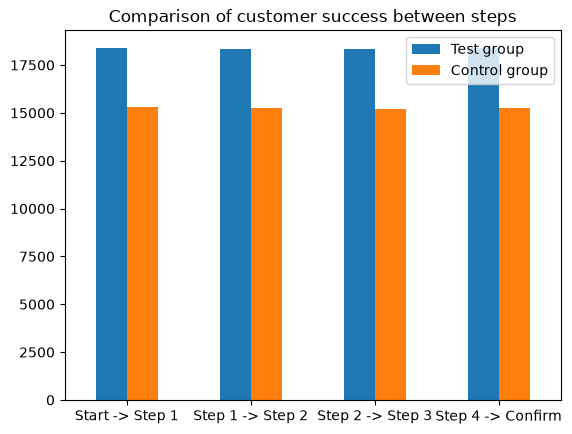

In [281]:
list_test_funnel = (test_funnel_1_2, test_funnel_2_3, test_funnel_3_4, test_funnel_4_5)
list_control_funnel = (control_funnel_1_2, control_funnel_2_3, control_funnel_3_4, control_funnel_4_5)
categ = ['Start -> Step 1', 'Step 1 -> Step 2', 'Step 2 -> Step 3', 'Step 4 -> Confirm']

df_barplot = pd.DataFrame({'Test group': list_test_funnel, 'Control group': list_control_funnel}, index = categ)

df_barplot.plot.bar(rot=0)

plt.title('Comparison of customer success between steps')
plt.show()

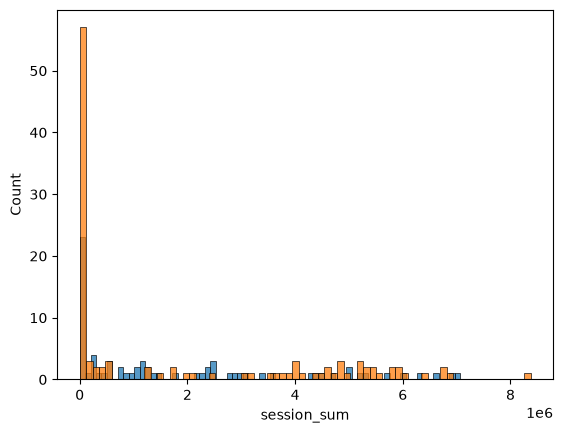

In [276]:
c_gr_s["session_sum"]
t_gr_s["session_sum"]

fig, axes = plt.subplots()
#axes.axvline(t_gr_s["session_sum"].mean(), color="black", linestyle="--")
sns.histplot(t_gr_s["session_sum"], bins=70, ax=axes);
sns.histplot(c_gr_s["session_sum"], bins=70, ax=axes);
plt.show()

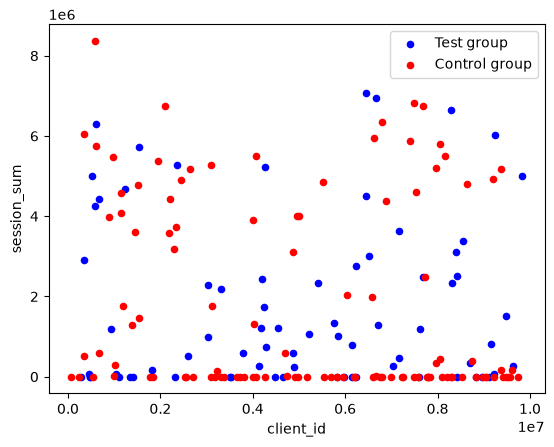

In [279]:
fig, ax = plt.subplots()
t_gr_s.plot.scatter(x='client_id', y='session_sum', color='blue', label='Test group', ax=ax)
c_gr_s.plot.scatter(x='client_id', y='session_sum', color='red', label='Control group', ax=ax)
plt.show()

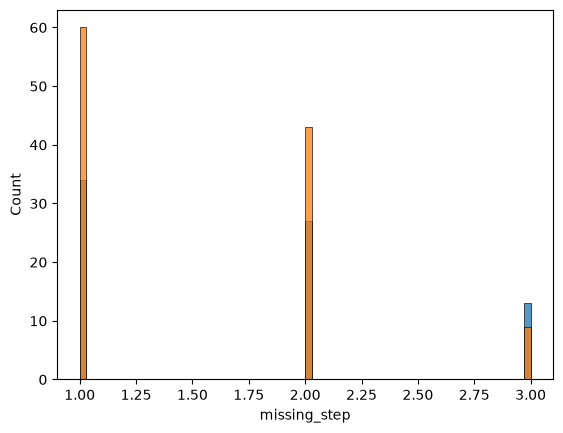

In [283]:

fig, axes = plt.subplots()
#axes.axvline(t_gr_s["session_sum"].mean(), color="black", linestyle="--")
sns.histplot(t_gr_s["missing_step"], bins=70, ax=axes);
sns.histplot(c_gr_s["missing_step"], bins=70, ax=axes);
plt.show()

## Correlation between parameters

In [287]:
df_main_test = pd.merge(t_gr_s, client_info_df, on='client_id', how='left') 
df_main_test

,client_id,process_step,session_sum,missing_step,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,279311,"[1, 2, 3, 5]",303,1,6.0,82.0,76.5,U,2.0,36187.66,0.0,3.0
1,342070,"[1, 2, 4, 5]",2914752,1,4.0,57.0,58.5,U,2.0,329936.54,6.0,9.0
2,445481,"[1, 4, 5]",70216,2,22.0,275.0,74.5,U,2.0,106930.99,0.0,3.0
3,467229,"[1, 2, 4, 5]",837,1,26.0,317.0,76.0,M,2.0,158530.30,4.0,7.0
4,483740,"[1, 2, 4, 5]",248,1,21.0,253.0,53.5,M,4.0,481915.70,6.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...
69,9221013,"[1, 2, 3, 5]",68364,1,16.0,195.0,42.5,M,2.0,23936.74,0.0,3.0
70,9247659,"[1, 2, 5]",6014657,2,26.0,318.0,74.5,F,3.0,543457.02,4.0,7.0
71,9478703,"[1, 2, 4, 5]",1512233,1,14.0,179.0,37.5,F,2.0,30773.69,5.0,8.0
72,9640116,"[1, 4, 5]",277584,2,6.0,78.0,24.5,U,2.0,51972.78,6.0,9.0


In [288]:
df_main_control = pd.merge(c_gr_s, client_info_df, on='client_id', how='left') 
df_main_control

,client_id,process_step,session_sum,missing_step,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,69255,"[1, 4, 5]",807,2,10.0,121.0,58.5,F,3.0,183269.84,6.0,9.0
1,239815,"[1, 2, 3, 5]",72,1,4.0,56.0,51.5,M,2.0,610818.28,6.0,9.0
2,338164,"[1, 2, 4, 5]",515383,1,10.0,122.0,63.5,M,2.0,408125.42,5.0,8.0
3,356380,"[1, 2, 5]",6051347,2,37.0,447.0,73.0,F,3.0,459026.19,6.0,9.0
4,537901,"[1, 2, 3, 5]",1189,1,15.0,181.0,40.5,M,2.0,137001.69,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
107,9484909,"[1, 2, 4, 5]",223,1,7.0,94.0,20.5,U,2.0,51542.32,0.0,3.0
108,9523156,"[1, 2, 3, 5]",309,1,19.0,235.0,37.5,M,2.0,133197.31,0.0,3.0
109,9565614,"[1, 2, 4, 5]",238,1,13.0,156.0,44.5,F,2.0,33428.33,1.0,4.0
110,9605388,"[1, 2, 4, 5]",156001,1,7.0,88.0,34.5,U,2.0,48848.32,6.0,9.0


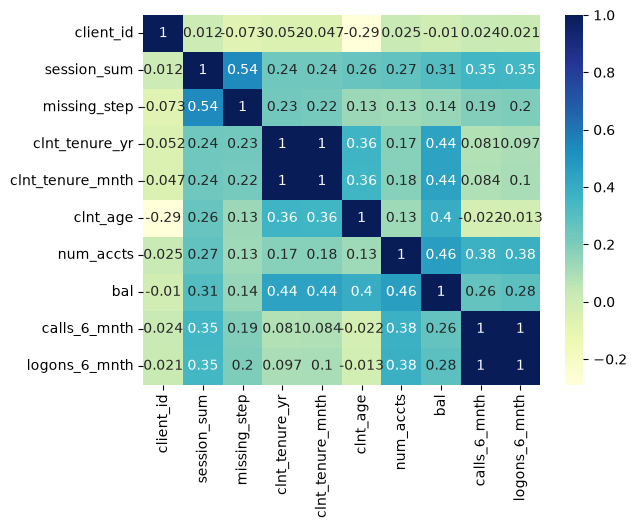

In [292]:
co_matrix_test = df_main_test.corr(numeric_only=True)

sns.heatmap(co_matrix_test, cmap="YlGnBu", annot=True)

plt.show()

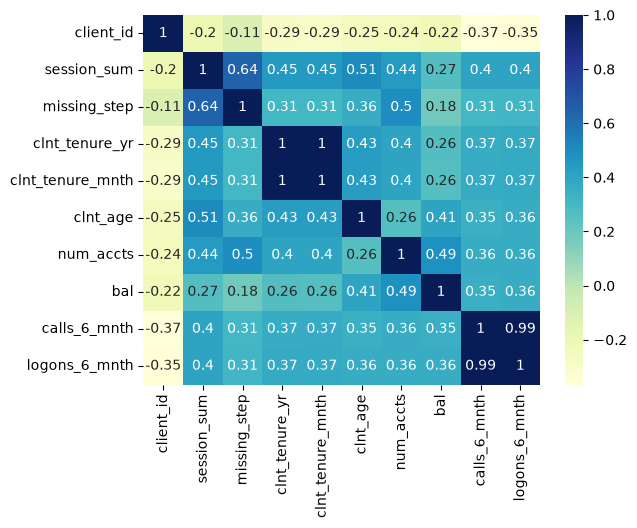

In [294]:
co_matrix_control = df_main_control.corr(numeric_only=True)

sns.heatmap(co_matrix_control, cmap="YlGnBu", annot=True)

plt.show()